# Testing of packet delay register control - CRACO-113


In [1]:
from pylab import *
import dpkt
import numpy as np
import glob
%matplotlib notebook

In [5]:
! ls data/packet_delays/


header_fpga1.txt       mlx50_d10_c2_f3.pcap    setup_d0.3.log
header_fpga2.txt       mlx50_d1500_c2_f3.pcap  setup_d0.log
header_fpga3.txt       mlx50_d30_c2_f3.pcap    setup_d100.log
header_fpga4.txt       mlx51_d0.3.pcap	       setup_d10.log
header_fpga5.txt       mlx51_d0.pcap	       setup_d1500.log
header_fpga6.txt       mlx51_d100_c2_f3.pcap   setup_d30.log
mlx50_d0.3.pcap        mlx51_d10_c2_f3.pcap    test.fits
mlx50_d0.pcap	       mlx51_d1500_c2_f3.pcap
mlx50_d100_c2_f3.pcap  mlx51_d30_c2_f3.pcap


In [27]:
fin0 = 'data/packet_delays/mlx50_d1500_c2_f3_v2.pcap'
fin1 = 'data/packet_delays/mlx51_d1500_c2_f3_v2.pcap'



def load(fin):
    times = []
    lens = []


    for ts, pkt in dpkt.pcap.Reader(open(fin, 'rb')):
        times.append(ts)
        lens.append(len(pkt))


    times = np.array(times)
    lens = np.array(lens)
    
    return (times, lens)


times0, lens0 = load(fin0)
times1, lens1 = load(fin1)


<IPython.core.display.Javascript object>


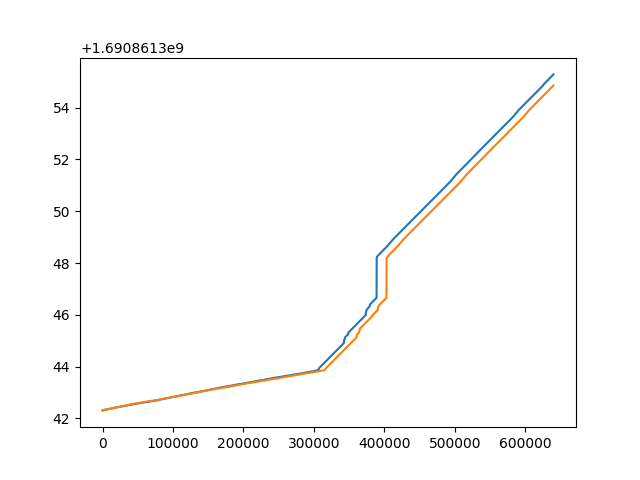

In [28]:
figure()
plot(times0)
plot(times1)

<IPython.core.display.Javascript object>


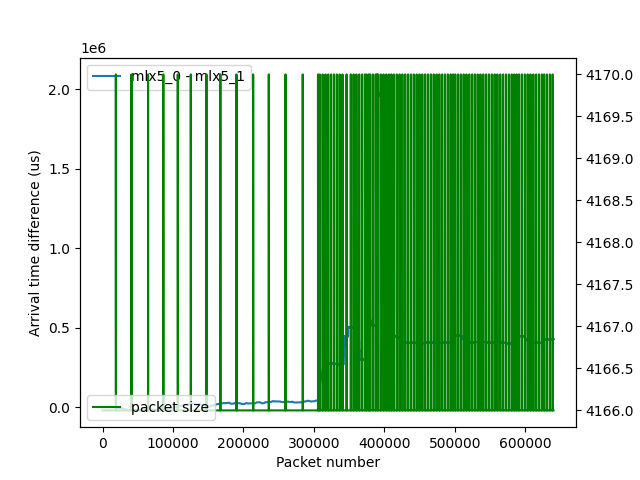

In [29]:
figure()
plot((times0-times1)*1e6, label='mlx5_0 - mlx5_1')
xlabel('Packet number')
ylabel('Arrival time difference (us)')
legend(loc='upper left')
twinx()
plot(lens0,'g', label='packet size')
xlabel('Packet size (bytes)')
legend(loc='lower left')
